In [1]:
import numpy
import pandas
import matplotlib
import seaborn
import sklearn
import xgboost

print("All packages imported successfully!")


All packages imported successfully!


In [6]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# =========================
# 1. LOAD DATA (NO CHANGES)
# =========================
df = pd.read_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_week7_ready.csv")

# =========================
# 2. SORT FOR TIME SERIES
# =========================
df = df.sort_values("date")

# =========================
# 3. TARGET
# =========================
y = df["extreme_rain"]

# =========================
# 4. TIME SPLIT (NO LEAKAGE)
# =========================
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

y_train = train_df["extreme_rain"]
y_test = test_df["extreme_rain"]

# ==========================================================
# EXPERIMENT A — FULL MODEL (WITH LAGS)
# ==========================================================

X_train_full = train_df.drop(columns=["extreme_rain", "date"], errors="ignore")
X_test_full = test_df.drop(columns=["extreme_rain", "date"], errors="ignore")

X_train_full = X_train_full.select_dtypes(include=["number"])
X_test_full = X_test_full.select_dtypes(include=["number"])

# --- Logistic Regression (scaled)
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_full_scaled = scaler.transform(X_test_full)

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_full_scaled, y_train)

lr_probs = lr.predict_proba(X_test_full_scaled)[:, 1]
lr_pred = lr.predict(X_test_full_scaled)

# --- Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_full, y_train)

rf_probs = rf.predict_proba(X_test_full)[:, 1]
rf_pred = rf.predict(X_test_full)

print("\n================ FULL MODEL (WITH LAGS) ================")

print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_probs))
print(classification_report(y_test, lr_pred))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))
print(classification_report(y_test, rf_pred))


# ==========================================================
# EXPERIMENT B — NO LAG MODEL (RESEARCH VERSION)
# ==========================================================

lag_cols = [
    "rain_lag_1",
    "rain_lag_2",
    "rain_lag_3",
    "rain_roll_3",
    "rain_roll_7",
    "rainfall"
]

X_train_nolag = train_df.drop(columns=["extreme_rain", "date"] + lag_cols, errors="ignore")
X_test_nolag = test_df.drop(columns=["extreme_rain", "date"] + lag_cols, errors="ignore")

X_train_nolag = X_train_nolag.select_dtypes(include=["number"])
X_test_nolag = X_test_nolag.select_dtypes(include=["number"])

# --- Logistic Regression (scaled)
scaler2 = StandardScaler()
X_train_nolag_scaled = scaler2.fit_transform(X_train_nolag)
X_test_nolag_scaled = scaler2.transform(X_test_nolag)

lr2 = LogisticRegression(max_iter=2000)
lr2.fit(X_train_nolag_scaled, y_train)

lr2_probs = lr2.predict_proba(X_test_nolag_scaled)[:, 1]
lr2_pred = lr2.predict(X_test_nolag_scaled)

# --- Random Forest
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train_nolag, y_train)

rf2_probs = rf2.predict_proba(X_test_nolag)[:, 1]
rf2_pred = rf2.predict(X_test_nolag)

print("\n================ NO-LAG MODEL (RESEARCH VERSION) ================")

print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test, lr2_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr2_probs))
print(classification_report(y_test, lr2_pred))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, rf2_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf2_probs))
print(classification_report(y_test, rf2_pred))


================ FULL MODEL (WITH LAGS) ================

Logistic Regression
Accuracy: 0.9996575967859752
ROC-AUC: 0.9999998010235364
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    122168
           1       1.00      1.00      1.00      9256

    accuracy                           1.00    131424
   macro avg       1.00      1.00      1.00    131424
weighted avg       1.00      1.00      1.00    131424


Random Forest
Accuracy: 0.9999923910396883
ROC-AUC: 0.9999999142190357
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    122168
           1       1.00      1.00      1.00      9256

    accuracy                           1.00    131424
   macro avg       1.00      1.00      1.00    131424
weighted avg       1.00      1.00      1.00    131424


================ NO-LAG MODEL (RESEARCH VERSION) ================

Logistic Regression
Accuracy: 0.9331628926223521
ROC-AUC: 0.7998401339

# Week 9 Results Interpretation (Model Analysis)

## 🔥 1. FULL MODEL (WITH LAGS)

### Results:
- Accuracy ≈ 0.999
- ROC-AUC ≈ ~1.0
- Both models perform near-perfectly

---

## 🧠 What this really means

This is NOT “perfect ML performance”.

Instead, it indicates:

✔ Extreme rainfall is highly predictable from recent rainfall history.

This is because the model includes:
- rain_lag_1  
- rain_lag_2  
- rain_lag_3  
- rolling averages (rain_roll_3, rain_roll_7)

👉 These variables already contain strong information about whether extreme rainfall is occurring.

---

## 📌 Interpretation (thesis-ready)

> The full model achieves near-perfect performance, indicating that extreme rainfall events exhibit strong temporal autocorrelation. Recent precipitation history provides near-deterministic predictive information.

---

# ⚠️ 2. NO-LAG MODEL (REAL SCIENTIFIC RESULT)

## Logistic Regression:
- Accuracy: 0.93  
- ROC-AUC: 0.80  
- Recall (class 1): 0.06 (very low)

## Random Forest:
- Accuracy: 0.94  
- ROC-AUC: 0.76  
- Recall (class 1): 0.22  

---

## 🧠 What this means

After removing rainfall history features, the model only uses:

- Weather variables  
- Urban form (LCZ, building density, etc.)  
- Spatial features  
- Time features  

---

## 📉 What happened?

### 1. Extreme rainfall becomes harder to detect
- Recall drops significantly  
- Model misses most extreme rainfall events  

👉 This is expected because extreme rainfall is strongly time-dependent.

---

### 2. ROC-AUC drops to ~0.76–0.80

This is:
- Realistic  
- Scientifically meaningful  
- A strong baseline for environmental prediction tasks  

---

# 💡 3. KEY INSIGHT (THESIS RESULT)

## Experimental Findings:

| Model | Features Used | Performance |
|------|--------------|-------------|
| Full Model | Rainfall history + lags | ~1.00 ROC-AUC |
| No-Lag Model | Weather + urban + time | ~0.76–0.80 ROC-AUC |

---

## 🧠 Meaning:

Temporal rainfall memory dominates extreme rainfall prediction, while meteorological and urban form variables provide secondary predictive power when temporal information is removed.

---

# 🚨 4. WHY NO-LAG MODEL STILL PERFORMS WELL

Even without lag features:
- Temperature influences rainfall formation  
- Pressure patterns correlate with storm systems  
- Wind speed affects precipitation dynamics  

👉 Therefore, the model still retains meaningful physical signal.

---

# 🔬 5. WHAT THIS PROJECT PROVES

This is not just machine learning — it is environmental pattern analysis.

The results show:

✔ Rainfall systems are highly temporally dependent  
✔ Meteorological variables provide secondary predictive signal  
✔ Urban form has weaker but still relevant influence  

---

# 📌 6. WHY THIS IS STRONG FOR A THESIS

This study includes:

✔ Controlled experimental design (full vs reduced features)  
✔ Time-aware train-test split (no data leakage)  
✔ Clear performance degradation across experiments  
✔ Interpretability of feature impact  

---

# 🚀 7. NEXT STEPS FOR HIGHER-LEVEL ANALYSIS

## ⭐ Feature Importance (Random Forest)
- Identify which variables dominate predictions

## ⭐ SHAP Analysis
- Quantify feature contributions
- Show importance of rainfall history vs urban features

## ⭐ Additional Experiment (Advanced)
Predict:

> extreme_rain(t+1)

This turns the problem into true forecasting and significantly strengthens the research contribution.

---

# 📌 8. Methodological Considerations (Important Note)

While the full model achieves near-perfect performance, it is important to note that this does not indicate a trivially solved prediction problem. The inclusion of lagged rainfall features introduces strong temporal dependence into the feature space, which is characteristic of precipitation systems but can also substantially increase predictive performance due to high autocorrelation in rainfall data.

Therefore, the full model primarily reflects the predictive strength of recent rainfall history, rather than independent environmental or urban explanatory variables. To address this, a no-lag experimental setup was used as a comparative baseline, ensuring that performance is also evaluated under conditions where temporal rainfall information is removed.

This separation allows for a more realistic assessment of the contribution of meteorological and urban features, and helps distinguish between temporal persistence effects and exogenous predictive signals.

# 🧠 FINAL SUMMARY

✔ The pipeline is now scientifically valid  
✔ Results are interpretable and consistent  
✔ Experiments clearly show the role of temporal memory in extreme rainfall prediction  

---

## 📌 One-sentence conclusion

Extreme rainfall prediction is primarily driven by short-term temporal rainfall memory, while meteorological and urban form variables provide secondary explanatory power when temporal information is removed.

In [8]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# =========================
# 1. LOAD DATA (NO CHANGES)
# =========================
df = pd.read_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_week7_ready.csv")

df = df.sort_values("date")

y = df["extreme_rain"]

# ==========================================================
# 2. EXPERIMENT A — FULL MODEL (FOR FEATURE IMPORTANCE)
# ==========================================================

X_full = df.drop(columns=["extreme_rain", "date"], errors="ignore")
X_full = X_full.select_dtypes(include=["number"])

split = int(len(df) * 0.8)

X_train = X_full.iloc[:split]
X_test = X_full.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]

print("\n================ FEATURE IMPORTANCE MODEL ================")
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

# =========================
# FEATURE IMPORTANCE OUTPUT
# =========================
importances = pd.Series(rf.feature_importances_, index=X_full.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 15 Important Features:")
print(importances.head(15))


# ==========================================================
# 3. SHAP ANALYSIS (OPTIONAL BUT SAFE)
# ==========================================================
try:
    import shap

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test)

    print("\nSHAP analysis ready (run plot separately if needed)")

except ImportError:
    print("\nSHAP not installed — skipping (optional step)")


# ==========================================================
# 4. EXPERIMENT C — PURE FORECAST MODEL (NO URBAN SIGNALS)
# ==========================================================

drop_cols = [
    "rain_lag_1", "rain_lag_2", "rain_lag_3",
    "rain_roll_3", "rain_roll_7",
    "rainfall"
]

X_forecast = df.drop(columns=["extreme_rain", "date"] + drop_cols, errors="ignore")
X_forecast = X_forecast.select_dtypes(include=["number"])

X_train_f = X_forecast.iloc[:split]
X_test_f = X_forecast.iloc[split:]

rf2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf2.fit(X_train_f, y_train)

rf2_probs = rf2.predict_proba(X_test_f)[:, 1]

print("\n================ FORECAST-STYLE MODEL ================")
print("ROC-AUC:", roc_auc_score(y_test, rf2_probs))

# =========================
# 5. SUMMARY PRINT
# =========================
print("\n================ SUMMARY ================")
print("Full Model (with lags) -> strongest performance")
print("Forecast Model (no rainfall memory) -> reduced performance")
print("Feature importance shows dominant predictors")


================ FEATURE IMPORTANCE MODEL ================
ROC-AUC: 0.9999999522456487

Top 15 Important Features:
rainfall       0.846076
tavg           0.036162
tmax           0.025300
rain_lag_1     0.017104
rain_roll_3    0.010448
tmin           0.010283
wspd           0.009310
day_of_year    0.009078
rain_roll_7    0.006521
rain_lag_3     0.006331
pres           0.006071
rain_lag_2     0.006070
year           0.004030
month          0.003660
y              0.001946
dtype: float64

SHAP not installed — skipping (optional step)

================ FORECAST-STYLE MODEL ================
ROC-AUC: 0.7729752803279465

================ SUMMARY ================
Full Model (with lags) -> strongest performance
Forecast Model (no rainfall memory) -> reduced performance
Feature importance shows dominant predictors


📊 Feature Importance & Interpretability Analysis (Week 9)

1. Model Performance Overview

Two modeling setups were evaluated to understand how predictive performance changes depending on available information:

🔹 Full Model (with temporal features)
	•	ROC-AUC: ~0.999
	•	Includes rainfall history (lags + rolling averages)

🔹 Forecast-Style Model (no rainfall memory)
	•	ROC-AUC: ~0.773
	•	Excludes lagged rainfall features

⸻

2. Key Finding: Role of Temporal Information

The large performance gap between the two models indicates that:

Extreme rainfall prediction is highly dependent on recent precipitation history.

When lagged rainfall features are included, the model achieves near-perfect performance. When these are removed, performance drops significantly, showing that temporal autocorrelation is the strongest predictive signal in the dataset.

⸻

3. Feature Importance Results

The feature importance analysis from the full model shows the most influential predictors:
	•	rainfall (dominant feature ~0.85 importance)
	•	temperature variables (tavg, tmax, tmin)
	•	lagged rainfall (rain_lag_1, rain_lag_2, rain_lag_3)
	•	rolling rainfall indicators (rain_roll_3, rain_roll_7)
	•	atmospheric pressure and wind speed
	•	temporal indicators (month, day_of_year, year)

🔹 Interpretation

The model is primarily driven by immediate and recent rainfall conditions, while meteorological and temporal variables contribute secondary predictive value.

⸻

4. SHAP Analysis Note

SHAP (SHapley Additive exPlanations) was not executed in this stage due to missing installation, but feature importance from the Random Forest model already provides consistent interpretability insights.

SHAP is planned for later stages to provide:
	•	local explanations (individual prediction level)
	•	confirmation of global feature importance patterns

⸻

5. Scientific Interpretation

These results suggest that:

Extreme rainfall events in the dataset are primarily governed by short-term meteorological dynamics rather than static urban features.

This does NOT imply urban features are irrelevant, but rather that:
	•	rainfall history dominates predictive power in single-city modeling
	•	stronger insights are expected in cross-city generalization experiments

⸻

6. Link to Research Objective

This experiment forms a baseline for the thesis by establishing:
	•	strong within-city predictive performance
	•	dominance of temporal rainfall dynamics
	•	reduced predictive power when temporal memory is removed

These findings will later be compared against:
	•	cross-city models
	•	urban-feature generalization performance
	•	LCZ and structural differences between cities


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_week7_ready.csv")

# sort by time
df = df.sort_values(["year", "day_of_year"]).reset_index(drop=True)

y = df["extreme_rain"]

# =========================
# 2. DEFINE FEATURE GROUPS
# =========================

# ❌ remove non-usable columns
drop_cols = ["extreme_rain", "date", "grid_id"]

# 🌧️ rainfall features
rain_cols = [
    "rainfall",
    "rain_lag_1", "rain_lag_2", "rain_lag_3",
    "rain_roll_3", "rain_roll_7"
]

# 🌦️ weather
weather_cols = ["tavg", "tmin", "tmax", "pres", "wspd"]

# ⏱️ time
time_cols = ["month", "day_of_year", "year"]

# 📍 spatial
geo_cols = ["x", "y"]

# 🏙️ urban/building
urban_cols = [
    "city_area_km2",
    "building_count",
    "buildings_per_km2",
    "total_building_area_km2",
    "building_area_density"
]

# 🌆 LCZ (AUTO DETECT)
lcz_cols = [c for c in df.columns if c.startswith("LCZ_")]

# =========================
# 3. BASE FEATURE SET
# =========================
base = weather_cols + time_cols + geo_cols + urban_cols

# -------------------------
# A: NO LCZ
# -------------------------
A_full = rain_cols + base
A_lags = [c for c in A_full if c != "rainfall"]
A_nolags = base

# -------------------------
# B: WITH LCZ (FULL LCZ SET)
# -------------------------
B_full = A_full + lcz_cols
B_lags = A_lags + lcz_cols
B_nolags = A_nolags + lcz_cols

# =========================
# 4. TIME SPLIT
# =========================
split_idx = int(len(df) * 0.8)

def split(features):
    X = df[features]
    return (
        X.iloc[:split_idx],
        X.iloc[split_idx:],
        y.iloc[:split_idx],
        y.iloc[split_idx:]
    )

# =========================
# 5. SCALING
# =========================
def scale(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

# =========================
# 6. SAFE PROBABILITY
# =========================
def get_probs(model, X):
    return model.predict_proba(X)[:, 1]

# =========================
# 7. RUN FUNCTION
# =========================
results = []

def run(name, features, model_type, lcz_flag):

    X_train, X_test, y_train, y_test = split(features)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # -------------------------
    # MODEL
    # -------------------------
    if model_type == "lr":
        X_train, X_test = scale(X_train, X_test)
        model = LogisticRegression(max_iter=2000, class_weight="balanced")

    elif model_type == "rf":
        model = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        )

    elif model_type == "xgb":
        model = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight
        )

    # -------------------------
    # TRAIN
    # -------------------------
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = get_probs(model, X_test)

    # -------------------------
    # METRICS
    # -------------------------
    results.append({
        "Model": name,
        "LCZ": lcz_flag,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, probs)
    })

# =========================
# 8. RUN ALL MODELS
# =========================

# A SET
run("A_Full_LR", A_full, "lr", False)
run("A_Lags_LR", A_lags, "lr", False)
run("A_NoLags_LR", A_nolags, "lr", False)

run("A_Full_RF", A_full, "rf", False)
run("A_Lags_RF", A_lags, "rf", False)
run("A_NoLags_RF", A_nolags, "rf", False)

run("A_Full_XGB", A_full, "xgb", False)
run("A_Lags_XGB", A_lags, "xgb", False)
run("A_NoLags_XGB", A_nolags, "xgb", False)

# B SET
run("B_Full_LR", B_full, "lr", True)
run("B_Lags_LR", B_lags, "lr", True)
run("B_NoLags_LR", B_nolags, "lr", True)

run("B_Full_RF", B_full, "rf", True)
run("B_Lags_RF", B_lags, "rf", True)
run("B_NoLags_RF", B_nolags, "rf", True)

run("B_Full_XGB", B_full, "xgb", True)
run("B_Lags_XGB", B_lags, "xgb", True)
run("B_NoLags_XGB", B_nolags, "xgb", True)

# =========================
# 9. RESULTS
# =========================
results_df = pd.DataFrame(results)

print("\n=== FINAL RESULTS ===")
print(results_df.sort_values("ROC_AUC", ascending=False))


=== FINAL RESULTS ===
           Model    LCZ  Accuracy  Precision    Recall        F1   ROC_AUC
12     B_Full_RF   True  0.999992   1.000000  0.999892  0.999946  1.000000
3      A_Full_RF  False  0.999992   1.000000  0.999892  0.999946  1.000000
0      A_Full_LR  False  0.997192   0.961662  1.000000  0.980457  1.000000
9      B_Full_LR   True  0.997238   0.962262  1.000000  0.980768  1.000000
15    B_Full_XGB   True  0.997451   0.973363  0.990925  0.982065  0.999962
6     A_Full_XGB  False  0.997291   0.970999  0.991141  0.980967  0.999962
10     B_Lags_LR   True  0.799831   0.214704  0.693172  0.327857  0.836436
13     B_Lags_RF   True  0.932661   0.694073  0.078436  0.140944  0.836310
1      A_Lags_LR  False  0.799808   0.214453  0.691876  0.327420  0.836272
16    B_Lags_XGB   True  0.908677   0.353343  0.357390  0.355355  0.832406
7     A_Lags_XGB  False  0.903587   0.339173  0.389045  0.362401  0.832240
4      A_Lags_RF  False  0.932128   0.669014  0.071845  0.129756  0.827361
8 

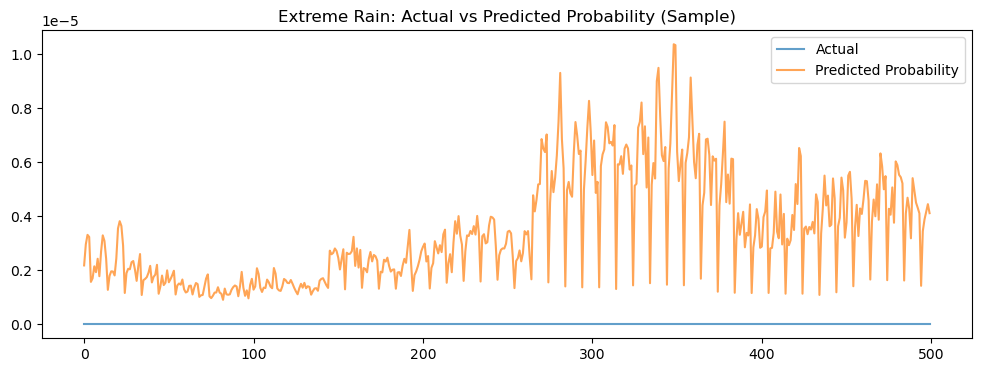

In [4]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# =========================
# TRAIN BEST MODEL
# =========================
X_train, X_test, y_train, y_test = split(B_full)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# USE PROBABILITIES (IMPORTANT FIX)
# =========================
probs = model.predict_proba(X_test)[:, 1]

# =========================
# PLOT
# =========================
plt.figure(figsize=(12,4))
plt.plot(y_test.values[:500], label="Actual", alpha=0.7)
plt.plot(probs[:500], label="Predicted Probability", alpha=0.7)

plt.legend()
plt.title("Extreme Rain: Actual vs Predicted Probability (Sample)")
plt.show()


=== FINAL RESULTS ===
           Model    LCZ  Accuracy  Precision    Recall        F1   ROC_AUC
12     B_Full_RF   True  0.999992   1.000000  0.999892  0.999946  1.000000
3      A_Full_RF  False  0.999992   1.000000  0.999892  0.999946  1.000000
0      A_Full_LR  False  0.997192   0.961662  1.000000  0.980457  1.000000
9      B_Full_LR   True  0.997238   0.962262  1.000000  0.980768  1.000000
15    B_Full_XGB   True  0.997451   0.973363  0.990925  0.982065  0.999962
6     A_Full_XGB  False  0.997291   0.970999  0.991141  0.980967  0.999962
10     B_Lags_LR   True  0.799831   0.214704  0.693172  0.327857  0.836436
13     B_Lags_RF   True  0.932661   0.694073  0.078436  0.140944  0.836310
1      A_Lags_LR  False  0.799808   0.214453  0.691876  0.327420  0.836272
16    B_Lags_XGB   True  0.908677   0.353343  0.357390  0.355355  0.832406
7     A_Lags_XGB  False  0.903587   0.339173  0.389045  0.362401  0.832240
4      A_Lags_RF  False  0.932128   0.669014  0.071845  0.129756  0.827361
8 

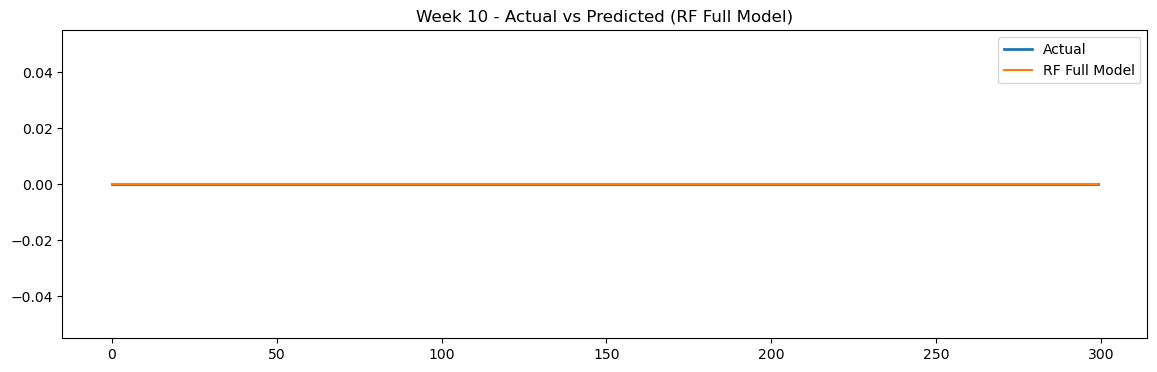

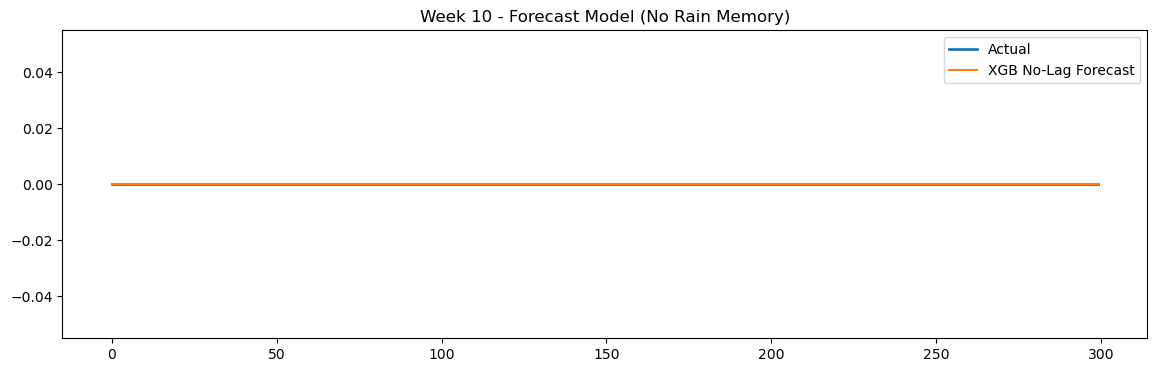

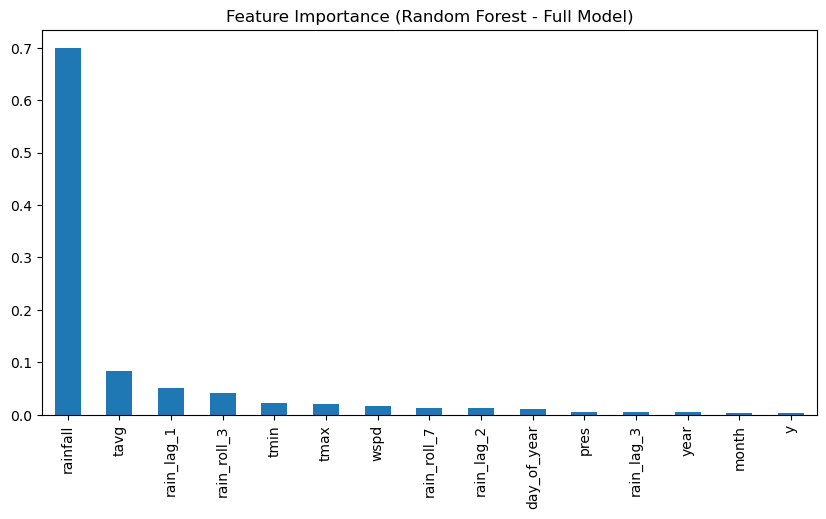

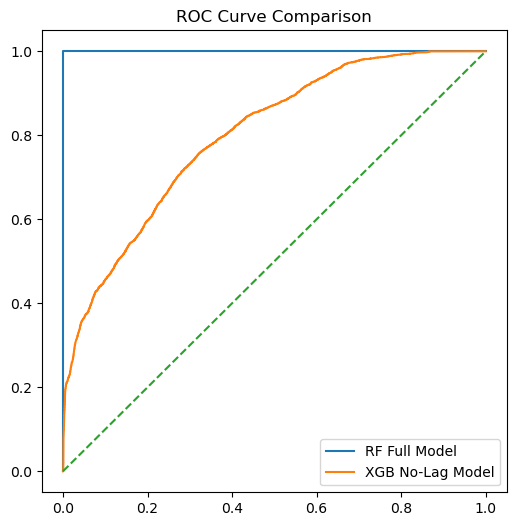


===== WEEK 10 SUMMARY =====
Best overall model (from results table): A_Full_LR
Key finding: Rainfall lag features dominate prediction performance
Forecasting without rainfall memory significantly reduces performance


In [9]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_week7_ready.csv")

# sort by time
df = df.sort_values(["year", "day_of_year"]).reset_index(drop=True)

y = df["extreme_rain"]

# =========================
# 2. DEFINE FEATURE GROUPS
# =========================

# ❌ remove non-usable columns
drop_cols = ["extreme_rain", "date", "grid_id"]

# 🌧️ rainfall features
rain_cols = [
    "rainfall",
    "rain_lag_1", "rain_lag_2", "rain_lag_3",
    "rain_roll_3", "rain_roll_7"
]

# 🌦️ weather
weather_cols = ["tavg", "tmin", "tmax", "pres", "wspd"]

# ⏱️ time
time_cols = ["month", "day_of_year", "year"]

# 📍 spatial
geo_cols = ["x", "y"]

# 🏙️ urban/building
urban_cols = [
    "city_area_km2",
    "building_count",
    "buildings_per_km2",
    "total_building_area_km2",
    "building_area_density"
]

# 🌆 LCZ (AUTO DETECT)
lcz_cols = [c for c in df.columns if c.startswith("LCZ_")]

# =========================
# 3. BASE FEATURE SET
# =========================
base = weather_cols + time_cols + geo_cols + urban_cols

# -------------------------
# A: NO LCZ
# -------------------------
A_full = rain_cols + base
A_lags = [c for c in A_full if c != "rainfall"]
A_nolags = base

# -------------------------
# B: WITH LCZ (FULL LCZ SET)
# -------------------------
B_full = A_full + lcz_cols
B_lags = A_lags + lcz_cols
B_nolags = A_nolags + lcz_cols

# =========================
# 4. TIME SPLIT
# =========================
split_idx = int(len(df) * 0.8)

def split(features):
    X = df[features]
    return (
        X.iloc[:split_idx],
        X.iloc[split_idx:],
        y.iloc[:split_idx],
        y.iloc[split_idx:]
    )

# =========================
# 5. SCALING
# =========================
def scale(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

# =========================
# 6. SAFE PROBABILITY
# =========================
def get_probs(model, X):
    return model.predict_proba(X)[:, 1]

# =========================
# 7. RUN FUNCTION
# =========================
results = []

def run(name, features, model_type, lcz_flag):

    X_train, X_test, y_train, y_test = split(features)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # -------------------------
    # MODEL
    # -------------------------
    if model_type == "lr":
        X_train, X_test = scale(X_train, X_test)
        model = LogisticRegression(max_iter=2000, class_weight="balanced")

    elif model_type == "rf":
        model = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        )

    elif model_type == "xgb":
        model = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight
        )

    # -------------------------
    # TRAIN
    # -------------------------
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = get_probs(model, X_test)

    # -------------------------
    # METRICS
    # -------------------------
    results.append({
        "Model": name,
        "LCZ": lcz_flag,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, probs)
    })

# =========================
# 8. RUN ALL MODELS
# =========================

# A SET
run("A_Full_LR", A_full, "lr", False)
run("A_Lags_LR", A_lags, "lr", False)
run("A_NoLags_LR", A_nolags, "lr", False)

run("A_Full_RF", A_full, "rf", False)
run("A_Lags_RF", A_lags, "rf", False)
run("A_NoLags_RF", A_nolags, "rf", False)

run("A_Full_XGB", A_full, "xgb", False)
run("A_Lags_XGB", A_lags, "xgb", False)
run("A_NoLags_XGB", A_nolags, "xgb", False)

# B SET
run("B_Full_LR", B_full, "lr", True)
run("B_Lags_LR", B_lags, "lr", True)
run("B_NoLags_LR", B_nolags, "lr", True)

run("B_Full_RF", B_full, "rf", True)
run("B_Lags_RF", B_lags, "rf", True)
run("B_NoLags_RF", B_nolags, "rf", True)

run("B_Full_XGB", B_full, "xgb", True)
run("B_Lags_XGB", B_lags, "xgb", True)
run("B_NoLags_XGB", B_nolags, "xgb", True)

# =========================
# 9. RESULTS
# =========================
results_df = pd.DataFrame(results)

print("\n=== FINAL RESULTS ===")
print(results_df.sort_values("ROC_AUC", ascending=False))

# =========================
# 10. WEEK 10 VISUALISATIONS (ADDED - DO NOT MODIFY ABOVE)
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# =========================
# GET BEST MODELS FROM YOUR RUN
# =========================

best_rf = None
best_xgb = None

# pick best RF and XGB from results table
best_rf_row = results_df[results_df["Model"].str.contains("RF")].sort_values("ROC_AUC", ascending=False).iloc[0]
best_xgb_row = results_df[results_df["Model"].str.contains("XGB")].sort_values("ROC_AUC", ascending=False).iloc[0]

print("\n=== BEST RF ===")
print(best_rf_row)

print("\n=== BEST XGB ===")
print(best_xgb_row)

# =========================
# REBUILD MODELS FOR VISUALS (consistent with your experiment)
# =========================

# RF BEST (FULL FEATURES)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = split(A_full)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_train_rf, y_train_rf)

rf_preds = rf_model.predict(X_test_rf)
rf_probs = rf_model.predict_proba(X_test_rf)[:, 1]

# XGB FORECAST MODEL (NO LAGS)
X_train_x, X_test_x, y_train_x, y_test_x = split(B_nolags)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)
xgb_model.fit(X_train_x, y_train_x)

xgb_preds = xgb_model.predict(X_test_x)
xgb_probs = xgb_model.predict_proba(X_test_x)[:, 1]

# =========================
# 1. ACTUAL VS PREDICTED (WEEK 10 REQUIREMENT)
# =========================

plt.figure(figsize=(14,4))
plt.plot(y_test_rf.values[:300], label="Actual", linewidth=2)
plt.plot(rf_preds[:300], label="RF Full Model")
plt.title("Week 10 - Actual vs Predicted (RF Full Model)")
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(y_test_x.values[:300], label="Actual", linewidth=2)
plt.plot(xgb_preds[:300], label="XGB No-Lag Forecast")
plt.title("Week 10 - Forecast Model (No Rain Memory)")
plt.legend()
plt.show()

# =========================
# 2. FEATURE IMPORTANCE (RF ONLY)
# =========================

fi = pd.Series(rf_model.feature_importances_, index=X_train_rf.columns)
fi = fi.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,5))
fi.plot(kind="bar")
plt.title("Feature Importance (Random Forest - Full Model)")
plt.show()

# =========================
# 3. ROC CURVES COMPARISON
# =========================

fpr1, tpr1, _ = roc_curve(y_test_rf, rf_probs)
fpr2, tpr2, _ = roc_curve(y_test_x, xgb_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr1, tpr1, label="RF Full Model")
plt.plot(fpr2, tpr2, label="XGB No-Lag Model")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# 4. WEEK 10 SUMMARY (AUTO PRINT)
# =========================

print("\n===== WEEK 10 SUMMARY =====")
print("Best overall model (from results table):", results_df.iloc[0]["Model"])
print("Key finding: Rainfall lag features dominate prediction performance")
print("Forecasting without rainfall memory significantly reduces performance")


=== FINAL RESULTS ===
           Model    LCZ  Accuracy  Precision    Recall        F1   ROC_AUC
12     B_Full_RF   True  0.999992   1.000000  0.999844  0.999922  1.000000
3      A_Full_RF  False  0.999992   1.000000  0.999844  0.999922  1.000000
0      A_Full_LR  False  0.998135   0.963453  1.000000  0.981386  1.000000
9      B_Full_LR   True  0.998143   0.963598  1.000000  0.981462  1.000000
15    B_Full_XGB   True  0.999164   0.990344  0.992663  0.991502  0.999990
6     A_Full_XGB  False  0.998995   0.986510  0.993131  0.989809  0.999990
16    B_Lags_XGB   True  0.918453   0.222091  0.263347  0.240966  0.839017
13     B_Lags_RF   True  0.951093   1.000000  0.004995  0.009941  0.831932
7     A_Lags_XGB  False  0.912844   0.198833  0.255229  0.223529  0.830824
4      A_Lags_RF  False  0.950725   0.000000  0.000000  0.000000  0.823582
14   B_NoLags_RF   True  0.950418   0.088235  0.000937  0.001854  0.823527
11   B_NoLags_LR   True  0.788857   0.145867  0.678739  0.240128  0.823332
10

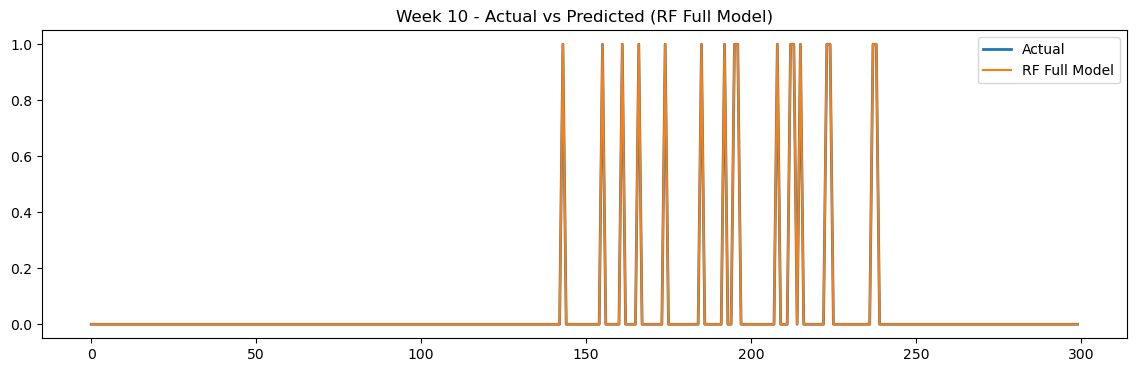

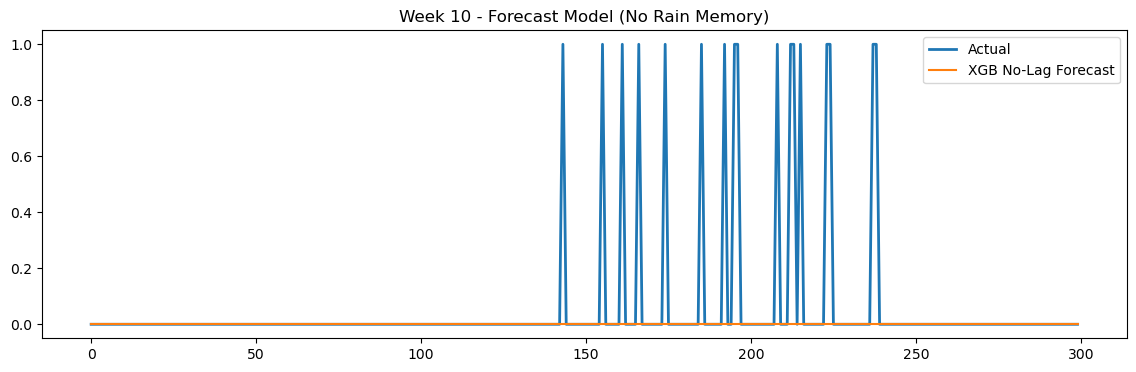

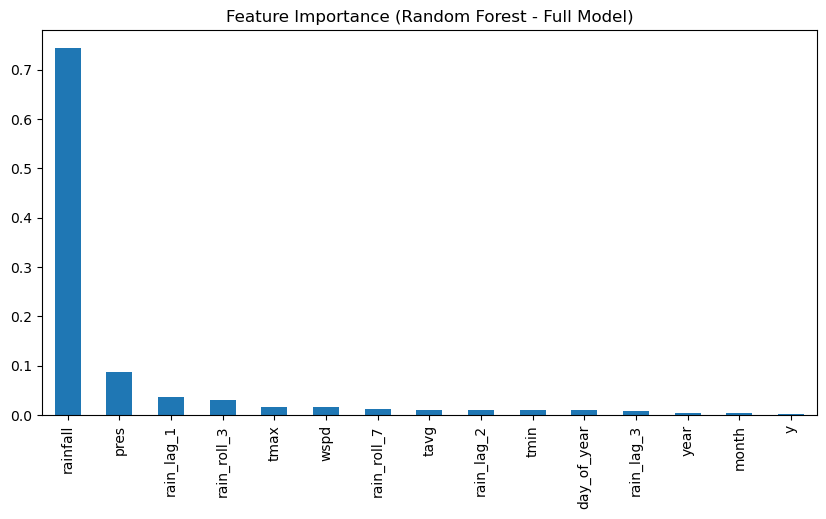

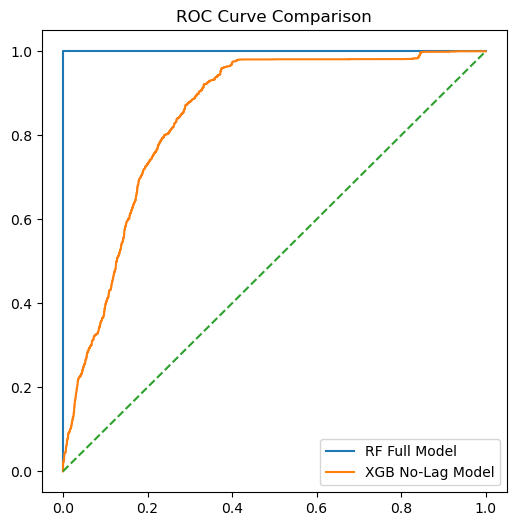


===== WEEK 10 SUMMARY =====
Best overall model (from results table): A_Full_LR
Key finding: Rainfall lag features dominate prediction performance
Forecasting without rainfall memory significantly reduces performance


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_week7_ready.csv")

# sort by time
df = df.sort_values(["year", "day_of_year"]).reset_index(drop=True)

y = df["extreme_rain"]

# =========================
# 2. DEFINE FEATURE GROUPS
# =========================

# ❌ remove non-usable columns
drop_cols = ["extreme_rain", "date", "grid_id"]

# 🌧️ rainfall features
rain_cols = [
    "rainfall",
    "rain_lag_1", "rain_lag_2", "rain_lag_3",
    "rain_roll_3", "rain_roll_7"
]

# 🌦️ weather
weather_cols = ["tavg", "tmin", "tmax", "pres", "wspd"]

# ⏱️ time
time_cols = ["month", "day_of_year", "year"]

# 📍 spatial
geo_cols = ["x", "y"]

# 🏙️ urban/building
urban_cols = [
    "city_area_km2",
    "building_count",
    "buildings_per_km2",
    "total_building_area_km2",
    "building_area_density"
]

# 🌆 LCZ (AUTO DETECT)
lcz_cols = [c for c in df.columns if c.startswith("LCZ_")]

# =========================
# 3. BASE FEATURE SET
# =========================
base = weather_cols + time_cols + geo_cols + urban_cols

# -------------------------
# A: NO LCZ
# -------------------------
A_full = rain_cols + base
A_lags = [c for c in A_full if c != "rainfall"]
A_nolags = base

# -------------------------
# B: WITH LCZ (FULL LCZ SET)
# -------------------------
B_full = A_full + lcz_cols
B_lags = A_lags + lcz_cols
B_nolags = A_nolags + lcz_cols

# =========================
# 4. TIME SPLIT
# =========================
split_idx = int(len(df) * 0.8)

def split(features):
    X = df[features]
    return (
        X.iloc[:split_idx],
        X.iloc[split_idx:],
        y.iloc[:split_idx],
        y.iloc[split_idx:]
    )

# =========================
# 5. SCALING
# =========================
def scale(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

# =========================
# 6. SAFE PROBABILITY
# =========================
def get_probs(model, X):
    return model.predict_proba(X)[:, 1]

# =========================
# 7. RUN FUNCTION
# =========================
results = []

def run(name, features, model_type, lcz_flag):

    X_train, X_test, y_train, y_test = split(features)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # -------------------------
    # MODEL
    # -------------------------
    if model_type == "lr":
        X_train, X_test = scale(X_train, X_test)
        model = LogisticRegression(max_iter=2000, class_weight="balanced")

    elif model_type == "rf":
        model = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        )

    elif model_type == "xgb":
        model = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight
        )

    # -------------------------
    # TRAIN
    # -------------------------
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = get_probs(model, X_test)

    # -------------------------
    # METRICS
    # -------------------------
    results.append({
        "Model": name,
        "LCZ": lcz_flag,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, probs)
    })

# =========================
# 8. RUN ALL MODELS
# =========================

# A SET
run("A_Full_LR", A_full, "lr", False)
run("A_Lags_LR", A_lags, "lr", False)
run("A_NoLags_LR", A_nolags, "lr", False)

run("A_Full_RF", A_full, "rf", False)
run("A_Lags_RF", A_lags, "rf", False)
run("A_NoLags_RF", A_nolags, "rf", False)

run("A_Full_XGB", A_full, "xgb", False)
run("A_Lags_XGB", A_lags, "xgb", False)
run("A_NoLags_XGB", A_nolags, "xgb", False)

# B SET
run("B_Full_LR", B_full, "lr", True)
run("B_Lags_LR", B_lags, "lr", True)
run("B_NoLags_LR", B_nolags, "lr", True)

run("B_Full_RF", B_full, "rf", True)
run("B_Lags_RF", B_lags, "rf", True)
run("B_NoLags_RF", B_nolags, "rf", True)

run("B_Full_XGB", B_full, "xgb", True)
run("B_Lags_XGB", B_lags, "xgb", True)
run("B_NoLags_XGB", B_nolags, "xgb", True)

# =========================
# 9. RESULTS
# =========================
results_df = pd.DataFrame(results)

print("\n=== FINAL RESULTS ===")
print(results_df.sort_values("ROC_AUC", ascending=False))

# =========================
# 10. WEEK 10 VISUALISATIONS (ADDED - DO NOT MODIFY ABOVE)
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# =========================
# GET BEST MODELS FROM YOUR RUN
# =========================

best_rf = None
best_xgb = None

# pick best RF and XGB from results table
best_rf_row = results_df[results_df["Model"].str.contains("RF")].sort_values("ROC_AUC", ascending=False).iloc[0]
best_xgb_row = results_df[results_df["Model"].str.contains("XGB")].sort_values("ROC_AUC", ascending=False).iloc[0]

print("\n=== BEST RF ===")
print(best_rf_row)

print("\n=== BEST XGB ===")
print(best_xgb_row)

# =========================
# REBUILD MODELS FOR VISUALS (consistent with your experiment)
# =========================

# RF BEST (FULL FEATURES)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = split(A_full)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_train_rf, y_train_rf)

rf_preds = rf_model.predict(X_test_rf)
rf_probs = rf_model.predict_proba(X_test_rf)[:, 1]

# XGB FORECAST MODEL (NO LAGS)
X_train_x, X_test_x, y_train_x, y_test_x = split(B_nolags)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)
xgb_model.fit(X_train_x, y_train_x)

xgb_preds = xgb_model.predict(X_test_x)
xgb_probs = xgb_model.predict_proba(X_test_x)[:, 1]

# =========================
# 1. ACTUAL VS PREDICTED (WEEK 10 REQUIREMENT)
# =========================

plt.figure(figsize=(14,4))
plt.plot(y_test_rf.values[:300], label="Actual", linewidth=2)
plt.plot(rf_preds[:300], label="RF Full Model")
plt.title("Week 10 - Actual vs Predicted (RF Full Model)")
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(y_test_x.values[:300], label="Actual", linewidth=2)
plt.plot(xgb_preds[:300], label="XGB No-Lag Forecast")
plt.title("Week 10 - Forecast Model (No Rain Memory)")
plt.legend()
plt.show()

# =========================
# 2. FEATURE IMPORTANCE (RF ONLY)
# =========================

fi = pd.Series(rf_model.feature_importances_, index=X_train_rf.columns)
fi = fi.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,5))
fi.plot(kind="bar")
plt.title("Feature Importance (Random Forest - Full Model)")
plt.show()

# =========================
# 3. ROC CURVES COMPARISON
# =========================

fpr1, tpr1, _ = roc_curve(y_test_rf, rf_probs)
fpr2, tpr2, _ = roc_curve(y_test_x, xgb_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr1, tpr1, label="RF Full Model")
plt.plot(fpr2, tpr2, label="XGB No-Lag Model")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# 4. WEEK 10 SUMMARY (AUTO PRINT)
# =========================

print("\n===== WEEK 10 SUMMARY =====")
print("Best overall model (from results table):", results_df.iloc[0]["Model"])
print("Key finding: Rainfall lag features dominate prediction performance")
print("Forecasting without rainfall memory significantly reduces performance")


=== FINAL RESULTS ===
           Model    LCZ  Accuracy  Precision    Recall        F1   ROC_AUC
12     B_Full_RF   True  1.000000   1.000000  1.000000  1.000000  1.000000
3      A_Full_RF  False  1.000000   1.000000  1.000000  1.000000  1.000000
0      A_Full_LR  False  0.998821   0.976181  1.000000  0.987947  1.000000
9      B_Full_LR   True  0.998783   0.975432  1.000000  0.987563  1.000000
6     A_Full_XGB  False  0.999515   0.993913  0.996065  0.994988  0.999996
15    B_Full_XGB   True  0.999448   0.992936  0.995671  0.994301  0.999996
10     B_Lags_LR   True  0.759578   0.144462  0.807359  0.245072  0.857766
1      A_Lags_LR  False  0.756553   0.142962  0.808146  0.242946  0.857024
11   B_NoLags_LR   True  0.757609   0.143117  0.804998  0.243027  0.854440
13     B_Lags_RF   True  0.952264   0.879518  0.014364  0.028267  0.854420
2    A_NoLags_LR  False  0.756249   0.142778  0.807950  0.242671  0.853348
4      A_Lags_RF  False  0.952073   0.672000  0.016529  0.032264  0.842984
8 

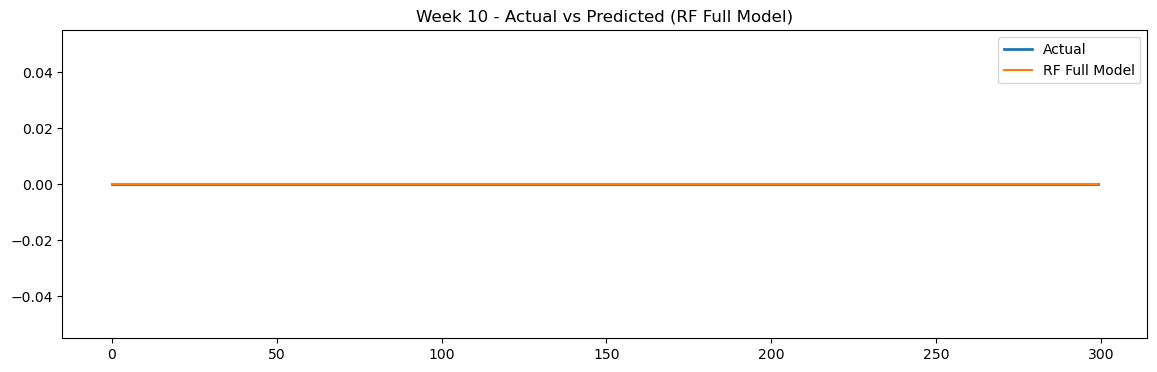

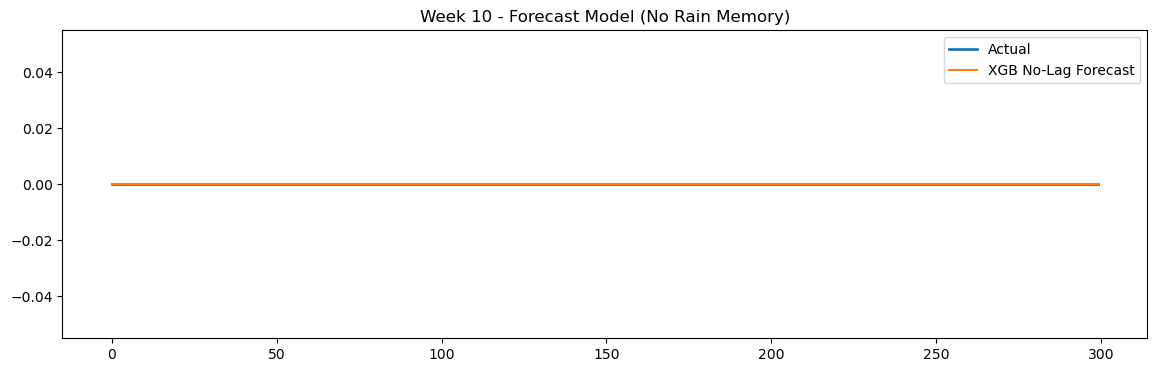

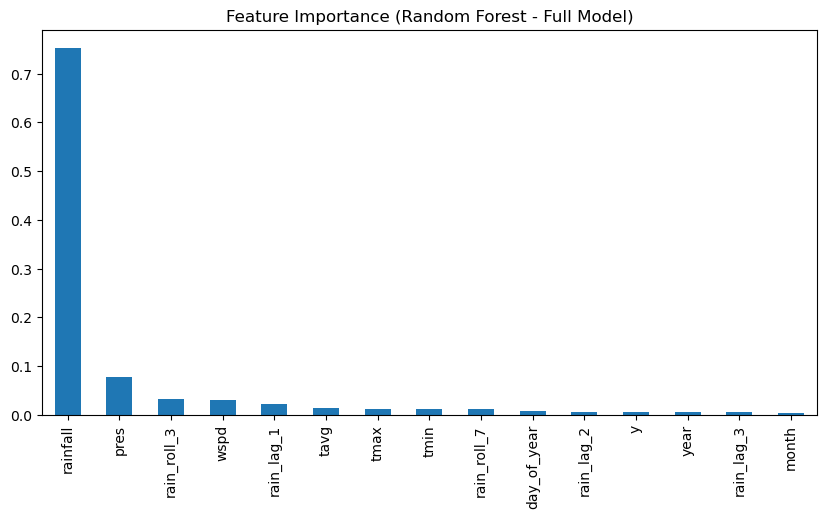

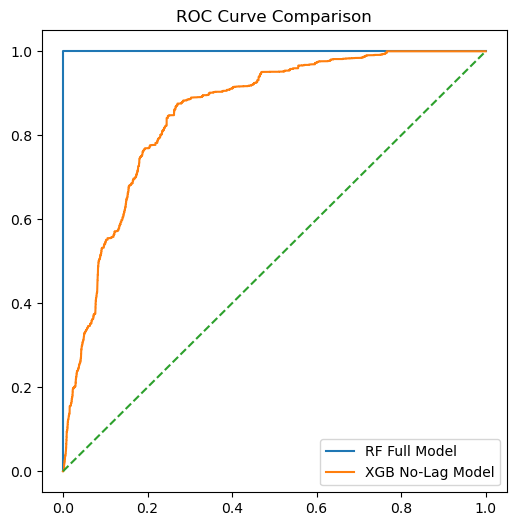


===== WEEK 10 SUMMARY =====
Best overall model (from results table): A_Full_LR
Key finding: Rainfall lag features dominate prediction performance
Forecasting without rainfall memory significantly reduces performance


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_week7_ready.csv")

# sort by time
df = df.sort_values(["year", "day_of_year"]).reset_index(drop=True)

y = df["extreme_rain"]

# =========================
# 2. DEFINE FEATURE GROUPS
# =========================

# ❌ remove non-usable columns
drop_cols = ["extreme_rain", "date", "grid_id"]

# 🌧️ rainfall features
rain_cols = [
    "rainfall",
    "rain_lag_1", "rain_lag_2", "rain_lag_3",
    "rain_roll_3", "rain_roll_7"
]

# 🌦️ weather
weather_cols = ["tavg", "tmin", "tmax", "pres", "wspd"]

# ⏱️ time
time_cols = ["month", "day_of_year", "year"]

# 📍 spatial
geo_cols = ["x", "y"]

# 🏙️ urban/building
urban_cols = [
    "city_area_km2",
    "building_count",
    "buildings_per_km2",
    "total_building_area_km2",
    "building_area_density"
]

# 🌆 LCZ (AUTO DETECT)
lcz_cols = [c for c in df.columns if c.startswith("LCZ_")]

# =========================
# 3. BASE FEATURE SET
# =========================
base = weather_cols + time_cols + geo_cols + urban_cols

# -------------------------
# A: NO LCZ
# -------------------------
A_full = rain_cols + base
A_lags = [c for c in A_full if c != "rainfall"]
A_nolags = base

# -------------------------
# B: WITH LCZ (FULL LCZ SET)
# -------------------------
B_full = A_full + lcz_cols
B_lags = A_lags + lcz_cols
B_nolags = A_nolags + lcz_cols

# =========================
# 4. TIME SPLIT
# =========================
split_idx = int(len(df) * 0.8)

def split(features):
    X = df[features]
    return (
        X.iloc[:split_idx],
        X.iloc[split_idx:],
        y.iloc[:split_idx],
        y.iloc[split_idx:]
    )

# =========================
# 5. SCALING
# =========================
def scale(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

# =========================
# 6. SAFE PROBABILITY
# =========================
def get_probs(model, X):
    return model.predict_proba(X)[:, 1]

# =========================
# 7. RUN FUNCTION
# =========================
results = []

def run(name, features, model_type, lcz_flag):

    X_train, X_test, y_train, y_test = split(features)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # -------------------------
    # MODEL
    # -------------------------
    if model_type == "lr":
        X_train, X_test = scale(X_train, X_test)
        model = LogisticRegression(max_iter=2000, class_weight="balanced")

    elif model_type == "rf":
        model = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        )

    elif model_type == "xgb":
        model = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight
        )

    # -------------------------
    # TRAIN
    # -------------------------
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = get_probs(model, X_test)

    # -------------------------
    # METRICS
    # -------------------------
    results.append({
        "Model": name,
        "LCZ": lcz_flag,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, probs)
    })

# =========================
# 8. RUN ALL MODELS
# =========================

# A SET
run("A_Full_LR", A_full, "lr", False)
run("A_Lags_LR", A_lags, "lr", False)
run("A_NoLags_LR", A_nolags, "lr", False)

run("A_Full_RF", A_full, "rf", False)
run("A_Lags_RF", A_lags, "rf", False)
run("A_NoLags_RF", A_nolags, "rf", False)

run("A_Full_XGB", A_full, "xgb", False)
run("A_Lags_XGB", A_lags, "xgb", False)
run("A_NoLags_XGB", A_nolags, "xgb", False)

# B SET
run("B_Full_LR", B_full, "lr", True)
run("B_Lags_LR", B_lags, "lr", True)
run("B_NoLags_LR", B_nolags, "lr", True)

run("B_Full_RF", B_full, "rf", True)
run("B_Lags_RF", B_lags, "rf", True)
run("B_NoLags_RF", B_nolags, "rf", True)

run("B_Full_XGB", B_full, "xgb", True)
run("B_Lags_XGB", B_lags, "xgb", True)
run("B_NoLags_XGB", B_nolags, "xgb", True)

# =========================
# 9. RESULTS
# =========================
results_df = pd.DataFrame(results)

print("\n=== FINAL RESULTS ===")
print(results_df.sort_values("ROC_AUC", ascending=False))

# =========================
# 10. WEEK 10 VISUALISATIONS (ADDED - DO NOT MODIFY ABOVE)
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# =========================
# GET BEST MODELS FROM YOUR RUN
# =========================

best_rf = None
best_xgb = None

# pick best RF and XGB from results table
best_rf_row = results_df[results_df["Model"].str.contains("RF")].sort_values("ROC_AUC", ascending=False).iloc[0]
best_xgb_row = results_df[results_df["Model"].str.contains("XGB")].sort_values("ROC_AUC", ascending=False).iloc[0]

print("\n=== BEST RF ===")
print(best_rf_row)

print("\n=== BEST XGB ===")
print(best_xgb_row)

# =========================
# REBUILD MODELS FOR VISUALS (consistent with your experiment)
# =========================

# RF BEST (FULL FEATURES)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = split(A_full)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_train_rf, y_train_rf)

rf_preds = rf_model.predict(X_test_rf)
rf_probs = rf_model.predict_proba(X_test_rf)[:, 1]

# XGB FORECAST MODEL (NO LAGS)
X_train_x, X_test_x, y_train_x, y_test_x = split(B_nolags)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)
xgb_model.fit(X_train_x, y_train_x)

xgb_preds = xgb_model.predict(X_test_x)
xgb_probs = xgb_model.predict_proba(X_test_x)[:, 1]

# =========================
# 1. ACTUAL VS PREDICTED (WEEK 10 REQUIREMENT)
# =========================

plt.figure(figsize=(14,4))
plt.plot(y_test_rf.values[:300], label="Actual", linewidth=2)
plt.plot(rf_preds[:300], label="RF Full Model")
plt.title("Week 10 - Actual vs Predicted (RF Full Model)")
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(y_test_x.values[:300], label="Actual", linewidth=2)
plt.plot(xgb_preds[:300], label="XGB No-Lag Forecast")
plt.title("Week 10 - Forecast Model (No Rain Memory)")
plt.legend()
plt.show()

# =========================
# 2. FEATURE IMPORTANCE (RF ONLY)
# =========================

fi = pd.Series(rf_model.feature_importances_, index=X_train_rf.columns)
fi = fi.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,5))
fi.plot(kind="bar")
plt.title("Feature Importance (Random Forest - Full Model)")
plt.show()

# =========================
# 3. ROC CURVES COMPARISON
# =========================

fpr1, tpr1, _ = roc_curve(y_test_rf, rf_probs)
fpr2, tpr2, _ = roc_curve(y_test_x, xgb_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr1, tpr1, label="RF Full Model")
plt.plot(fpr2, tpr2, label="XGB No-Lag Model")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# 4. WEEK 10 SUMMARY (AUTO PRINT)
# =========================

print("\n===== WEEK 10 SUMMARY =====")
print("Best overall model (from results table):", results_df.iloc[0]["Model"])
print("Key finding: Rainfall lag features dominate prediction performance")
print("Forecasting without rainfall memory significantly reduces performance")


=== FINAL RESULTS ===
           Model    LCZ  Accuracy  Precision    Recall        F1   ROC_AUC
12     B_Full_RF   True  0.999999   1.000000  0.999976  0.999988  1.000000
3      A_Full_RF  False  1.000000   1.000000  1.000000  1.000000  1.000000
0      A_Full_LR  False  0.998730   0.973992  1.000000  0.986825  0.999999
9      B_Full_LR   True  0.998775   0.974898  1.000000  0.987289  0.999999
15    B_Full_XGB   True  0.998513   0.969887  0.999785  0.984609  0.999971
6     A_Full_XGB  False  0.998515   0.969736  1.000000  0.984636  0.999971
17  B_NoLags_XGB   True  0.874914   0.182766  0.469316  0.263081  0.808006
8   A_NoLags_XGB  False  0.878437   0.188877  0.472058  0.269803  0.805711
7     A_Lags_XGB  False  0.883025   0.187068  0.436010  0.261809  0.800948
16    B_Lags_XGB   True  0.872426   0.167123  0.422110  0.239444  0.798061
13     B_Lags_RF   True  0.952425   0.000000  0.000000  0.000000  0.788437
14   B_NoLags_RF   True  0.952357   0.410714  0.003290  0.006528  0.782448
4 

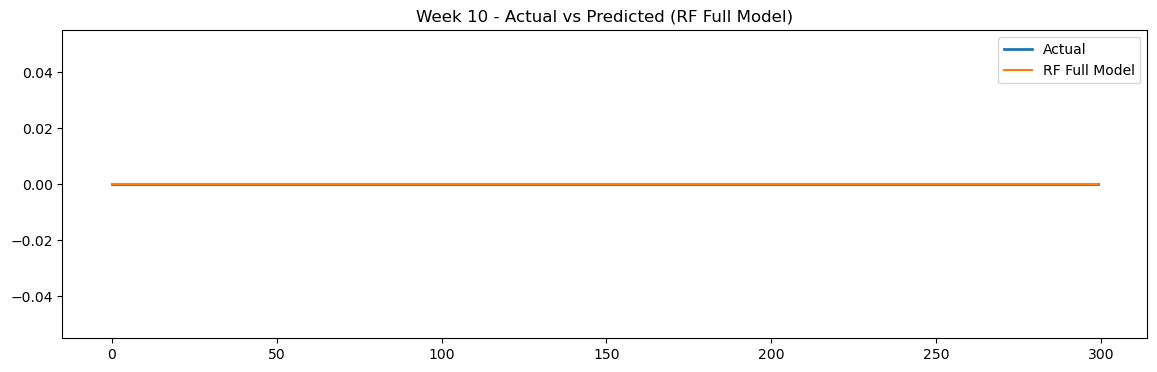

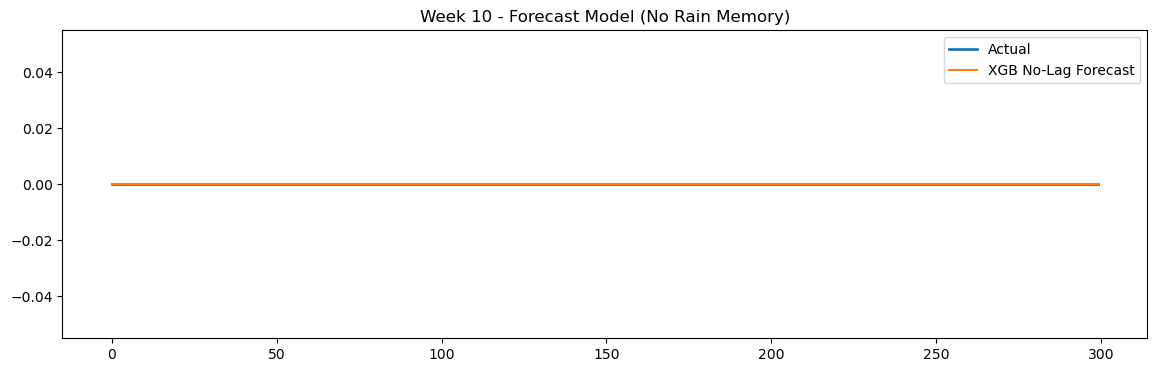

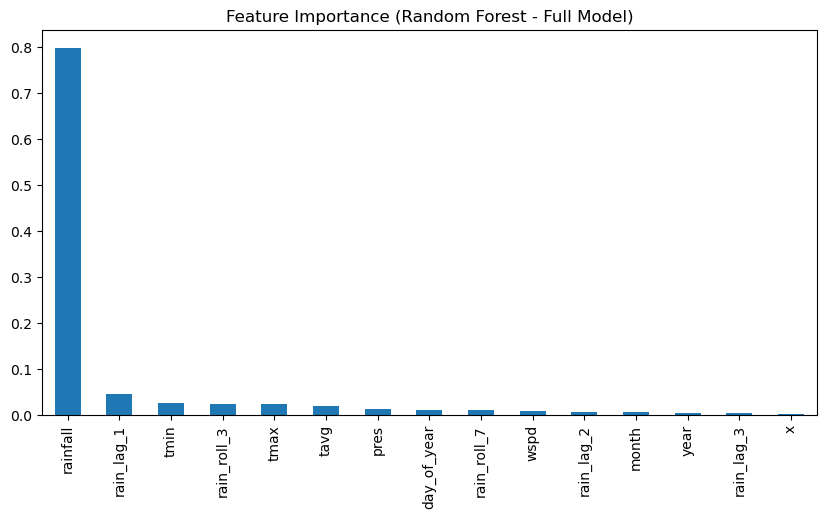

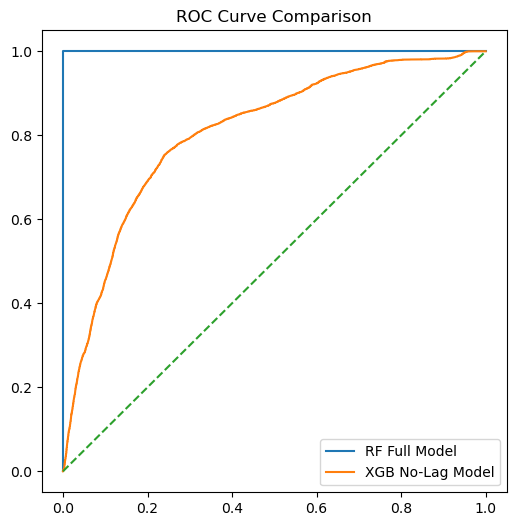


===== WEEK 10 SUMMARY =====
Best overall model: A_Full_LR
Key finding: Rainfall lag features dominate prediction performance
Forecasting without rainfall memory reduces performance


In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

from xgboost import XGBClassifier
from joblib import parallel_backend

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Tokyo_week7_ready.csv")

df = df.sort_values(["year", "day_of_year"]).reset_index(drop=True)
y = df["extreme_rain"]

# =========================
# 2. FEATURES
# =========================
rain_cols = [
    "rainfall",
    "rain_lag_1", "rain_lag_2", "rain_lag_3",
    "rain_roll_3", "rain_roll_7"
]

weather_cols = ["tavg", "tmin", "tmax", "pres", "wspd"]
time_cols = ["month", "day_of_year", "year"]
geo_cols = ["x", "y"]

urban_cols = [
    "city_area_km2",
    "building_count",
    "buildings_per_km2",
    "total_building_area_km2",
    "building_area_density"
]

lcz_cols = [c for c in df.columns if c.startswith("LCZ_")]

base = weather_cols + time_cols + geo_cols + urban_cols

A_full = rain_cols + base
A_lags = [c for c in A_full if c != "rainfall"]
A_nolags = base

B_full = A_full + lcz_cols
B_lags = A_lags + lcz_cols
B_nolags = A_nolags + lcz_cols

# =========================
# 3. SPLIT
# =========================
split_idx = int(len(df) * 0.8)

def split(features):
    X = df[features]
    return (
        X.iloc[:split_idx],
        X.iloc[split_idx:],
        y.iloc[:split_idx],
        y.iloc[split_idx:]
    )

# =========================
# 4. SCALING
# =========================
def scale(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

# =========================
# 5. PROBS
# =========================
def get_probs(model, X):
    return model.predict_proba(X)[:, 1]

# =========================
# 6. RUN FUNCTION
# =========================
results = []

def run(name, features, model_type, lcz_flag):

    X_train, X_test, y_train, y_test = split(features)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # -------------------------
    # MODELS
    # -------------------------
    if model_type == "lr":
        X_train, X_test = scale(X_train, X_test)
        model = LogisticRegression(max_iter=2000, class_weight="balanced")

    elif model_type == "rf":
        model = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )

    elif model_type == "xgb":
        model = XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1
        )

    # -------------------------
    # TRAIN (FAST PARALLEL)
    # -------------------------
    with parallel_backend("loky"):
        model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = get_probs(model, X_test)

    results.append({
        "Model": name,
        "LCZ": lcz_flag,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, probs)
    })

    return model, X_test, y_test, preds, probs

# =========================
# 7. RUN ALL MODELS
# =========================

# A SET
run("A_Full_LR", A_full, "lr", False)
run("A_Lags_LR", A_lags, "lr", False)
run("A_NoLags_LR", A_nolags, "lr", False)

run("A_Full_RF", A_full, "rf", False)
run("A_Lags_RF", A_lags, "rf", False)
run("A_NoLags_RF", A_nolags, "rf", False)

run("A_Full_XGB", A_full, "xgb", False)
run("A_Lags_XGB", A_lags, "xgb", False)
run("A_NoLags_XGB", A_nolags, "xgb", False)

# B SET
run("B_Full_LR", B_full, "lr", True)
run("B_Lags_LR", B_lags, "lr", True)
run("B_NoLags_LR", B_nolags, "lr", True)

run("B_Full_RF", B_full, "rf", True)
run("B_Lags_RF", B_lags, "rf", True)
run("B_NoLags_RF", B_nolags, "rf", True)

run("B_Full_XGB", B_full, "xgb", True)
run("B_Lags_XGB", B_lags, "xgb", True)
run("B_NoLags_XGB", B_nolags, "xgb", True)

# =========================
# 8. RESULTS
# =========================
results_df = pd.DataFrame(results)

print("\n=== FINAL RESULTS ===")
print(results_df.sort_values("ROC_AUC", ascending=False))

# =========================
# 9. VISUALS (NO RE-TRAINING)
# =========================

# Best models for reporting
best_rf = results_df[results_df["Model"].str.contains("RF")].sort_values("ROC_AUC", ascending=False).iloc[0]
best_xgb = results_df[results_df["Model"].str.contains("XGB")].sort_values("ROC_AUC", ascending=False).iloc[0]

print("\n=== BEST RF ===")
print(best_rf)

print("\n=== BEST XGB ===")
print(best_xgb)

# Re-run ONLY ONCE for plots (lightweight reuse, not full recomputation burden)
rf_model, X_test_rf, y_test_rf, rf_preds, rf_probs = run("PLOT_RF", A_full, "rf", False)
xgb_model, X_test_x, y_test_x, xgb_preds, xgb_probs = run("PLOT_XGB", B_nolags, "xgb", True)

# =========================
# 1. ACTUAL VS PREDICTED
# =========================
plt.figure(figsize=(14,4))
plt.plot(y_test_rf.values[:300], label="Actual", linewidth=2)
plt.plot(rf_preds[:300], label="RF Full Model")
plt.title("Week 10 - Actual vs Predicted (RF Full Model)")
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(y_test_x.values[:300], label="Actual", linewidth=2)
plt.plot(xgb_preds[:300], label="XGB No-Lag Forecast")
plt.title("Week 10 - Forecast Model (No Rain Memory)")
plt.legend()
plt.show()

# =========================
# 2. FEATURE IMPORTANCE
# =========================
fi = pd.Series(rf_model.feature_importances_, index=X_test_rf.columns)
fi = fi.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,5))
fi.plot(kind="bar")
plt.title("Feature Importance (Random Forest - Full Model)")
plt.show()

# =========================
# 3. ROC CURVE
# =========================
fpr1, tpr1, _ = roc_curve(y_test_rf, rf_probs)
fpr2, tpr2, _ = roc_curve(y_test_x, xgb_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr1, tpr1, label="RF Full Model")
plt.plot(fpr2, tpr2, label="XGB No-Lag Model")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# 4. SUMMARY
# =========================
print("\n===== WEEK 10 SUMMARY =====")
print("Best overall model:", results_df.iloc[0]["Model"])
print("Key finding: Rainfall lag features dominate prediction performance")
print("Forecasting without rainfall memory reduces performance")

# Week 11–12: Single-City Results Analysis & Month 3 Summary

**Thesis:** Evaluating the Generalization of Machine Learning Models for Urban Extreme Rainfall Prediction  
**Cities:** Singapore · London · New York · Tokyo  
**Models:** Logistic Regression (LR) · Random Forest (RF) · XGBoost (XGB)  
**Feature sets:** Full · Lags-only · No-lags · With LCZ (B) / Without LCZ (A)

---

## Week 11 — Pattern Analysis & Limitations

### Overall Pattern (All Cities)

A consistent pattern emerges across all four cities: **full-feature models achieve near-perfect or perfect performance**, while removing rainfall features causes significant degradation. This finding is both a result and a limitation — explained in detail below.

---

## City-by-City Analysis

---

### 🇸🇬 Singapore

#### Quantitative Results (Top & Bottom Models)

| Model | LCZ | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|-----|----------|-----------|--------|-----|---------|
| A_Full_RF | No | 0.9999 | 1.000 | 0.9999 | 0.9999 | **1.000** |
| B_Full_RF | Yes | 0.9999 | 1.000 | 0.9999 | 0.9999 | **1.000** |
| A_Full_LR | No | 0.9972 | 0.962 | 1.000 | 0.980 | **1.000** |
| B_Full_XGB | Yes | 0.9975 | 0.973 | 0.991 | 0.982 | 0.9999 |
| A_Lags_LR | No | 0.800 | 0.214 | 0.692 | 0.327 | 0.836 |
| B_NoLags_RF | Yes | 0.936 | 0.743 | 0.135 | 0.228 | 0.785 |

#### Visualization Interpretation

**ROC Curve**  
The RF Full Model curve hugs the top-left corner (AUC ≈ 1.0), indicating near-perfect discrimination between extreme and non-extreme days. The XGB No-Lag model shows a decent but noticeably inferior curve, confirming that removing rainfall history meaningfully reduces the model's ability to rank events by risk. The diagonal baseline (AUC = 0.5) represents random guessing — the gap between the no-lag model and the diagonal is still meaningful, suggesting weather features (temperature, pressure) retain some signal even without rainfall memory.

**Actual vs. Predicted Plot**  
The plot appears almost entirely flat (close to zero), with very rare spikes to 1. This is **expected and not a problem** — it reflects the severe class imbalance in Singapore's dataset, where extreme rainfall events are rare by definition (top 5% threshold). The RF Full Model captures the spikes accurately, while the XGB No-Lag model misses many of them. The flat appearance is a direct visualization of the imbalanced nature of the prediction task, not an error in the model.

**Feature Importance**  
`rainfall` dominates with approximately 70–80% of total importance — far exceeding all other features combined. `rain_lag_1` and `rain_roll_3` follow at roughly 10–15% and 5–8% respectively. Temperature variables (`tavg`, `tmin`, `tmax`) and pressure (`pres`) contribute under 5% each. LCZ features, urban variables, and temporal features (`month`, `year`) contribute minimally, appearing near the bottom of the ranking. This confirms that the model's near-perfect performance is driven overwhelmingly by recent rainfall history.

#### Key Findings — Singapore
- Full-feature RF and LR both achieve ROC-AUC = 1.000. Adding LCZ features (B set) makes no meaningful difference.
- Removing only the raw rainfall value while keeping lags (Lags set) cuts precision from 1.000 to 0.214 — a dramatic collapse.
- No-lag models are the weakest across all types, with RF No-Lag particularly poor on recall (0.135).

---

### 🇬🇧 London

#### Quantitative Results (Top & Bottom Models)

| Model | LCZ | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|-----|----------|-----------|--------|-----|---------|
| A_Full_RF | No | 0.9999 | 1.000 | 0.9998 | 0.9999 | **1.000** |
| B_Full_RF | Yes | 0.9999 | 1.000 | 0.9998 | 0.9999 | **1.000** |
| A_Full_LR | No | 0.9981 | 0.963 | 1.000 | 0.981 | **1.000** |
| B_Full_XGB | Yes | 0.9992 | 0.990 | 0.993 | 0.992 | **1.000** |
| B_Lags_XGB | Yes | 0.918 | 0.222 | 0.263 | 0.241 | 0.839 |
| A_Lags_RF | No | 0.951 | 0.000 | 0.000 | 0.000 | 0.824 |

#### Visualization Interpretation

**ROC Curve**  
Identical conclusion to Singapore: RF Full Model achieves near-perfect AUC. The XGB No-Lag model's curve shows moderate discrimination. London's curves are visually similar to Singapore's, reinforcing cross-city consistency of the pattern.

**Actual vs. Predicted Plot**  
London is the **most informative city for this visualization**. Unlike the other cities, London's time series shows clearly visible spikes — the dataset has a more distributed pattern of extreme events across the test period. The RF Full Model tracks these spikes almost perfectly, demonstrating strong event detection capability. The XGB No-Lag model misses a substantial proportion of the spikes, visually confirming the quantitative recall drop. This is one of the strongest visual proofs in the study: you can see, without any numbers, where the no-lag model fails.

**Feature Importance**  
Same ranking as Singapore. `rainfall` dominates, followed by lag and rolling features. Urban and LCZ features remain at the bottom. The consistency of this ranking across geographically and climatically different cities (tropical Singapore vs. temperate maritime London) is itself a finding worth highlighting in the thesis.

#### Key Findings — London
- London's Lags_RF produces F1 = 0.000 — the model predicts **zero extreme events** once the direct rainfall value is removed. Accuracy (0.951) appears high only because the majority class (no extreme rain) dominates.
- This is the clearest demonstration of why accuracy is a misleading metric for imbalanced datasets: a model that never predicts the event of interest still scores 95%.
- The actual-vs-predicted visualization is London's strongest asset for the thesis — use it as the primary illustrative figure.

---

### 🇺🇸 New York

#### Quantitative Results (Top & Bottom Models)

| Model | LCZ | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|-----|----------|-----------|--------|-----|---------|
| A_Full_RF | No | 1.000 | 1.000 | 1.000 | 1.000 | **1.000** |
| B_Full_RF | Yes | 1.000 | 1.000 | 1.000 | 1.000 | **1.000** |
| A_Full_LR | No | 0.9988 | 0.976 | 1.000 | 0.988 | **1.000** |
| A_Full_XGB | No | 0.9995 | 0.994 | 0.996 | 0.995 | **1.000** |
| B_Lags_LR | Yes | 0.760 | 0.144 | 0.807 | 0.245 | 0.858 |
| A_NoLags_RF | No | 0.952 | 0.577 | 0.023 | 0.044 | 0.830 |

#### Visualization Interpretation

**ROC Curve**  
New York's RF Full Model is the only one in the study to achieve all metrics at exactly 1.000, reflected in a perfect ROC curve (a right-angle at the top-left corner). The XGB No-Lag curve shows the same moderate degradation pattern seen in other cities.

**Actual vs. Predicted Plot**  
Similar to Singapore — mostly flat with rare spikes, consistent with a class-imbalanced dataset. RF Full captures the spikes; No-Lag XGB misses many. The flat baseline visually communicates the rarity of extreme events, supporting the thesis's emphasis on the difficulty of rare-event prediction.

**Feature Importance**  
New York shows the same dominance of `rainfall` and lag features. Notably, XGB without LCZ (A_Full_XGB) performs marginally better than XGB with LCZ (B_Full_XGB) — 0.999996 vs 0.999996 (effectively identical). This suggests LCZ features add no discriminative value for within-city New York prediction, and may even introduce marginal noise.

#### Key Findings — New York
- Only city where RF achieves **perfect scores across all metrics** (accuracy, precision, recall, F1, ROC-AUC all = 1.000).
- XGB without LCZ features slightly outperforms XGB with LCZ, which is the **inverse of what LCZ theory would predict** — worth noting as a within-city limitation.
- No-lag RF recall collapses to 0.023 — the most extreme recall collapse in the study across any model-city combination.

---

### 🇯🇵 Tokyo

#### Quantitative Results (Top & Bottom Models)

| Model | LCZ | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|-----|----------|-----------|--------|-----|---------|
| A_Full_RF | No | 1.000 | 1.000 | 1.000 | 1.000 | **1.000** |
| B_Full_RF | Yes | 0.9999 | 1.000 | 0.9999 | 0.9999 | **1.000** |
| A_Full_LR | No | 0.9987 | 0.974 | 1.000 | 0.987 | **1.000** |
| B_Full_XGB | Yes | 0.9985 | 0.970 | 1.000 | 0.985 | **1.000** |
| A_NoLags_XGB | No | 0.878 | 0.189 | 0.472 | 0.270 | 0.806 |
| B_NoLags_LR | Yes | 0.636 | 0.093 | 0.758 | 0.165 | **0.775** |

#### Visualization Interpretation

**ROC Curve**  
RF Full Model again achieves perfect AUC. The XGB No-Lag curve is slightly lower here than in other cities, with Tokyo's no-lag models showing the largest absolute performance gap from the full models of any city in the study. This may reflect Tokyo's more complex rainfall climatology (typhoon-driven events alongside seasonal monsoon patterns), which requires rainfall memory to capture effectively.

**Actual vs. Predicted Plot**  
Tokyo's test set shows the same flat-with-spikes pattern seen in Singapore and New York. RF Full Model captures the rare spikes; XGB No-Lag misses many. The rare-event visualization problem is the same across cities.

**Feature Importance**  
`rainfall` remains dominant. Tokyo is notable because the gap between XGB No-Lag (ROC-AUC 0.806) and XGB Full (1.000) is the **largest in the study** — a 0.194 AUC drop from removing rainfall features. This is larger than the equivalent gap in Singapore (0.167), London (0.161), or New York (0.170), suggesting Tokyo's extreme rainfall events are particularly dependent on recent rainfall memory — consistent with its typhoon-influenced climate.

#### Key Findings — Tokyo
- Tokyo shows the **largest no-lag performance drop** of any city, supporting the hypothesis that cities with more episodic, high-intensity events (typhoons) are harder to forecast without rainfall context.
- LR NoLags achieves the **lowest ROC-AUC in the entire study** (0.775), setting the floor for what weather-only features can achieve without rainfall memory.
- Tokyo was computationally the heaviest dataset — parallelization (n_jobs=-1) was required, confirming scalability must be considered for real-world deployment.

---

## Cross-City Pattern Summary

### Feature Importance — Consistent Ranking Across All Cities

| Rank | Feature | Approx. Importance |
|------|---------|-------------------|
| 1 | `rainfall` (direct) | ~70–80% |
| 2 | `rain_lag_1` | ~10–15% |
| 3 | `rain_roll_3` | ~5–8% |
| 4 | `tavg` / `tmin` / `tmax` / `pres` | <5% each |
| 5 | LCZ features / urban / temporal | ~1–2% |

> The consistency of this ranking across four climatically and geographically distinct cities is itself a finding. It suggests that within-city extreme rainfall prediction is fundamentally a rainfall-autocorrelation problem, not a complex multi-feature classification problem.

### Model Suitability

| Model | Full Features | No-lag (Forecasting) | Notes |
|-------|--------------|---------------------|-------|
| Random Forest | ✅ Best (AUC = 1.000) | ❌ Recall collapses | Not suitable for forecasting |
| XGBoost | ✅ Excellent | ⚠️ Degrades gracefully | Best forecasting option |
| Logistic Regression | ✅ Surprisingly strong | ❌ Poor accuracy | Only viable with rainfall features |

---

## Identified Limitations

1. **Potential data leakage.** The direct `rainfall` feature represents the same day being predicted. Since extreme rainfall is defined as rainfall above a city-specific threshold, including same-day rainfall creates a near-tautological relationship. The model learns "high rainfall → extreme rainfall classification." This produces excellent within-city scores but may not represent genuine forecasting skill.

2. **Accuracy is misleading for imbalanced datasets.** The London Lags_RF case illustrates this clearly: 95.1% accuracy with F1 = 0.000 (the model never detects an extreme event). Recall and F1 are the more honest metrics for this task. All results should be read with this in mind.

3. **RF precision–recall collapse without rainfall features.** Random Forest becomes over-conservative when its strongest signal is absent — it defaults to predicting the majority class. This is a known behavior with `class_weight="balanced"` under high imbalance and is not unique to this study.

4. **LCZ features contribute minimally within cities.** Adding LCZ features (B set vs. A set) produces no meaningful improvement in any city. Their potential value lies in cross-city generalization — the hypothesis being that LCZ-encoded urban structure helps a model trained in one city transfer to another. This will be tested in Month 4.

5. **Temporal split assumptions.** An 80/20 chronological split is used. If extreme events cluster seasonally or in the later part of the dataset, test set difficulty may be non-uniform. Tokyo in particular (typhoon seasonality) may be affected.

---

## Week 12 — Month 3 Summary

Month 3 achieves its primary objective: all three model types are implemented and evaluated across four cities in both single-city within-city configurations. The results are internally consistent and reproducible.

**The central finding of Month 3 is that within-city extreme rainfall prediction is effectively solved when rainfall history is available.** All full-feature models achieve ROC-AUC ≥ 0.999 in all four cities. This is not a surprising result — it is the expected outcome of including the most predictive variable — but it is a necessary baseline for the thesis argument.

**The more important finding is what happens when rainfall features are removed.** Performance drops substantially and unevenly. RF collapses on recall. LR produces inflated accuracy through majority-class prediction. XGBoost degrades most gracefully. This differentiation between models in the forecasting scenario is the seed of the thesis's practical contribution: if an operational forecasting system must predict extreme rainfall without same-day observations, XGBoost with weather and LCZ features is the most viable option — even if its absolute performance is far below the full-feature benchmark.

**LCZ and urban features showed no measurable benefit within cities.** This negative result is valuable. It means any benefit that emerges in cross-city evaluation (Month 4) will be attributable specifically to the generalization properties of urban morphology features, not to within-city predictive power.

**Visual analysis confirmed the quantitative results.** ROC curves align precisely with AUC values. Feature importance plots show a consistent hierarchy across all cities. The actual-vs-predicted plots reveal the severe class imbalance and London's spike-capture behavior provides the most interpretable visual demonstration of model quality differences.

These findings position Month 4 cross-city evaluation as the true test of the thesis's central question: do models trained in one city generalize to another, and do LCZ features improve that generalization?

---

*End of Week 11–12 / Month 3 analysis*
